# DAVIS Event Camera – Event Representations (modular version)



**How to tweak:** change values only in the `Config` cell (window length, τ, voxel bins, tile size, graph radii ...) and re-run the cells below it.

| Section | Functions |
|---|---|
| Config & loading | `Config`, `load_davis`, `inspect_dataset` |
| Event stats | `summarize_events`, `count_events_in_windows`, `select_window` |
| Dense | `make_count_frame`, `make_polarity_frame`, `make_sae`, `make_time_surface`, `make_voxel_grid` |
| Sparse | `make_tokens`, `build_graph`, point cloud (window itself) |
| Plots | `plot_*` (one per representation) |

## 0. Imports & Configuration

In [1]:
from dataclasses import dataclass
from typing import Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from scipy.spatial import cKDTree


@dataclass
class Config:
    # ---- dataset ----
    data_dir: str = "../data/DAVIS"
    recording: str = "shapes_6dof"

    # ---- observation window (all times in microseconds, us) ----
    window_start_us: Optional[int] = None   # None -> start at first event timestamp
    window_us: int = 1_000_000              # 1_000_000 us = 1 s

    # ---- sensor size (None -> inferred from max x / max y) ----
    sensor_size: Optional[Tuple[int, int]] = None   # (width, height), DAVIS240 = (240, 180)

    # ---- time surface ----
    tau_us: int = 200_000                   # decay constant (200_000 us = 200 ms)

    # ---- voxel grid ----
    num_bins: int = 10

    # ---- tokens ----
    tile_size: int = 16                     # pixels (tile_size x tile_size)
    token_time_us: int = 1_000              # temporal bin size (1000 us = 1 ms)
    token_bin_to_show: int = 0              # which time bin to scatter-plot

    # ---- graph ----
    graph_spatial_radius: float = 8         # pixels
    graph_temporal_radius_us: float = 500   # us
    max_edges_to_plot: int = 300

    # ---- misc ----
    sweep_windows_us: tuple = (1_000, 5_000, 10_000, 50_000, 100_000, 500_000, 1_000_000)


cfg = Config()
cfg

Config(data_dir='../data/DAVIS', recording='shapes_6dof', window_start_us=None, window_us=1000000, sensor_size=None, tau_us=200000, num_bins=10, tile_size=16, token_time_us=1000, token_bin_to_show=0, graph_spatial_radius=8, graph_temporal_radius_us=500, max_edges_to_plot=300, sweep_windows_us=(1000, 5000, 10000, 50000, 100000, 500000, 1000000))

## 1. Loading & inspecting the dataset

In [2]:
def load_davis(cfg: Config):
    """Load the DAVIS recording with Tonic. Returns (events, imu, frames, target)."""
    import tonic
    dataset = tonic.datasets.DAVISDATA(save_to=cfg.data_dir, recording=cfg.recording)
    print(dataset)
    print("Number of samples:", len(dataset))
    (events, imu, frames), target = dataset[0]
    return events, imu, frames, target


def inspect_dataset(events, imu, frames, target):
    """Print type / shape / keys of every raw item."""
    for name, item in [("events", events), ("imu", imu), ("frames", frames)]:
        print(f"\n{name}: type={type(item).__name__}")
        if isinstance(item, dict):
            print("  keys :", list(item.keys()))
        else:
            print("  shape:", getattr(item, "shape", None))
            print("  dtype:", getattr(item, "dtype", None))
    print("\ntarget keys:", list(target.keys()))


def print_first_events(events, n=10):
    for i in range(n):
        e = events[i]
        print(i, "t =", e["t"], "x =", e["x"], "y =", e["y"], "p =", e["p"])

In [3]:
events, imu, frames, target = load_davis(cfg)
inspect_dataset(events, imu, frames, target)
print_first_events(events)

DAVISDATA
Number of samples: 1

events: type=ndarray
  shape: (17962477,)
  dtype: [('t', '<i8'), ('x', '<i8'), ('y', '<i8'), ('p', '<i8')]

imu: type=dict
  keys : ['ts', 'rotQ', 'angV', 'acc', 'mag', 'rosbagType']

frames: type=dict
  keys : ['ts', 'frames', 'rosbagType']

target keys: ['ts', 'point', 'rotation', 'rosbagType']
0 t = 0 x = 50 y = 40 p = 0
1 t = 494 x = 216 y = 14 p = 0
2 t = 648 x = 156 y = 51 p = 1
3 t = 669 x = 57 y = 114 p = 1
4 t = 705 x = 208 y = 91 p = 1
5 t = 705 x = 203 y = 72 p = 0
6 t = 1060 x = 169 y = 158 p = 1
7 t = 1199 x = 195 y = 83 p = 1
8 t = 1299 x = 210 y = 23 p = 1
9 t = 1412 x = 207 y = 91 p = 1


## 2. Event statistics & windowing

In [4]:
def infer_sensor_size(events, cfg: Config):
    """Return (width, height)."""
    if cfg.sensor_size is not None:
        return cfg.sensor_size
    return int(events["x"].max()) + 1, int(events["y"].max()) + 1


def summarize_events(events):
    """Duration, average event rate, sensor size."""
    t = events["t"]
    duration_us = t[-1] - t[0]
    duration_s = duration_us / 1e6
    print("First timestamp :", t[0])
    print("Last timestamp  :", t[-1])
    print(f"Duration        : {duration_us} us = {duration_us/1e3} ms = {duration_s:.3f} s")
    print(f"Avg event rate  : {len(events)/duration_s:,.1f} Hz")


def select_window(events, t_start, t_end):
    """Events with t_start <= t < t_end."""
    t = events["t"]
    return events[(t >= t_start) & (t < t_end)]


def get_window(events, cfg: Config):
    """Apply cfg.window_start_us / cfg.window_us. Returns (window_events, t_start, t_end)."""
    t_start = events["t"][0] if cfg.window_start_us is None else cfg.window_start_us
    t_end = t_start + cfg.window_us
    return select_window(events, t_start, t_end), t_start, t_end


def count_events_in_windows(events, windows_us, t_start=0):
    """How many events fall in [t_start, t_start + w) for each w."""
    t = events["t"]
    for w in windows_us:
        n = np.sum((t >= t_start) & (t < t_start + w))
        print(f"{w/1000:>8} ms : {n:>8} events")

In [5]:
summarize_events(events)
width, height = infer_sensor_size(events, cfg)
print("Image width:", width, "height:", height)

count_events_in_windows(events, cfg.sweep_windows_us)

win, t_start, t_end = get_window(events, cfg)
print(f"\nWindow [{t_start}, {t_end}) us  ->  {len(win)} events")

First timestamp : 0
Last timestamp  : 59735406
Duration        : 59735406 us = 59735.406 ms = 59.735 s
Avg event rate  : 300,700.7 Hz
Image width: 240 height: 180
     1.0 ms :        6 events
     5.0 ms :       34 events
    10.0 ms :       65 events
    50.0 ms :      265 events
   100.0 ms :     1561 events
   500.0 ms :    12960 events
  1000.0 ms :    52362 events

Window [0, 1000000) us  ->  52362 events


## 3. Dense representations

In [6]:
def signed_polarity(p):
    """DAVIS polarity {0, 1} -> {-1, +1}."""
    return np.where(p == 1, 1, -1)


def make_count_frame(win, size):
    """1) Event-count image: number of events per pixel."""
    w, h = size
    frame = np.zeros((h, w), dtype=np.int32)
    np.add.at(frame, (win["y"], win["x"]), 1)
    return frame


def make_polarity_frame(win, size):
    """2) Polarity image: (#ON - #OFF) per pixel."""
    w, h = size
    frame = np.zeros((h, w), dtype=np.int32)
    np.add.at(frame, (win["y"], win["x"]), signed_polarity(win["p"]))
    return frame


def make_sae(win, size):
    """3a) Surface of Active Events: latest timestamp per pixel (0 = no event)."""
    w, h = size
    sae = np.zeros((h, w), dtype=np.int64)
    np.maximum.at(sae, (win["y"], win["x"]), win["t"])
    return sae


def sae_recency(sae, t_end):
    """3b) Time since last event (us). 0 where no event."""
    out = np.zeros_like(sae)
    valid = sae > 0
    out[valid] = t_end - sae[valid]
    return out


def sae_normalized(sae, t_start, t_end):
    """3c) SAE scaled to [0, 1] over the window. 0 where no event."""
    out = np.zeros(sae.shape, dtype=np.float32)
    valid = sae > 0
    out[valid] = (sae[valid] - t_start) / (t_end - t_start)
    return out


def make_time_surface(sae, t_now, tau_us):
    """4) Exponential time surface: exp(-(t_now - t_last) / tau)."""
    ts = np.zeros(sae.shape, dtype=np.float32)
    valid = sae > 0
    ts[valid] = np.exp(-(t_now - sae[valid]) / tau_us)
    return ts


def make_voxel_grid(win, size, t_start, t_end, num_bins):
    """5) Voxel grid (bins, H, W): signed polarity summed per temporal bin."""
    w, h = size
    grid = np.zeros((num_bins, h, w), dtype=np.float32)
    bin_idx = ((win["t"] - t_start) / (t_end - t_start) * num_bins).astype(int)
    bin_idx = np.clip(bin_idx, 0, num_bins - 1)
    np.add.at(grid, (bin_idx, win["y"], win["x"]), signed_polarity(win["p"]))
    return grid

### Plot helpers (dense)

In [7]:
def plot_image(img, title, cbar_label, cmap="gray", figsize=(8, 5)):
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap=cmap, origin="upper")
    plt.xlabel("x"); plt.ylabel("y"); plt.title(title)
    plt.colorbar(label=cbar_label)
    plt.show()


def plot_sae(sae, sae_norm, sae_rec):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    panels = [
        (sae,      "Raw SAE",        "Timestamp (us)"),
        (sae_norm, "Normalized SAE", "Normalized timestamp"),
        (sae_rec,  "SAE Recency",    "Recency (us)"),
    ]
    for ax, (img, title, label) in zip(axes, panels):
        im = ax.imshow(img, cmap="gray", origin="upper")
        ax.set_title(title); ax.set_xlabel("x"); ax.set_ylabel("y")
        fig.colorbar(im, ax=ax, label=label)
    plt.tight_layout()
    plt.show()


def plot_voxel_grid(grid, t_start, t_end, ncols=5):
    num_bins = grid.shape[0]
    nrows = int(np.ceil(num_bins / ncols))
    bin_us = (t_end - t_start) / num_bins
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.6 * ncols, 3.5 * nrows), squeeze=False)
    for b, ax in enumerate(axes.flat):
        if b >= num_bins:
            ax.axis("off"); continue
        ax.imshow(grid[b], cmap="gray", origin="upper")
        ax.set_title(f"Bin {b}\n{t_start + b*bin_us:.0f}-{t_start + (b+1)*bin_us:.0f} us")
        ax.set_xlabel("x"); ax.set_ylabel("y")
    plt.tight_layout()
    plt.show()

### 3.1 Event count image

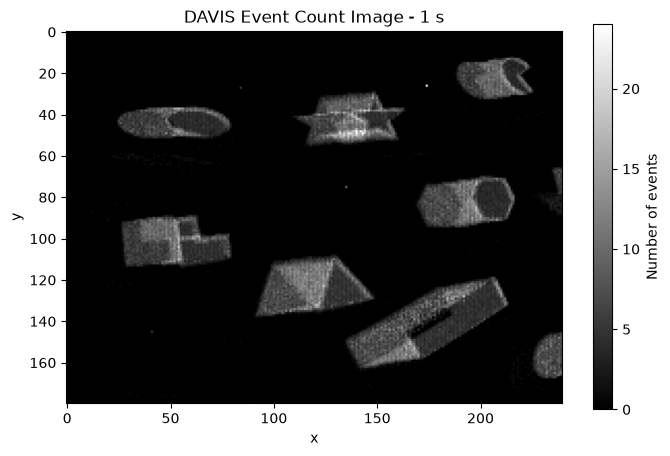

In [8]:
size = (width, height)
win_s = cfg.window_us / 1e6

count_frame = make_count_frame(win, size)
plot_image(count_frame, f"DAVIS Event Count Image - {win_s:g} s", "Number of events")

### 3.2 Polarity image

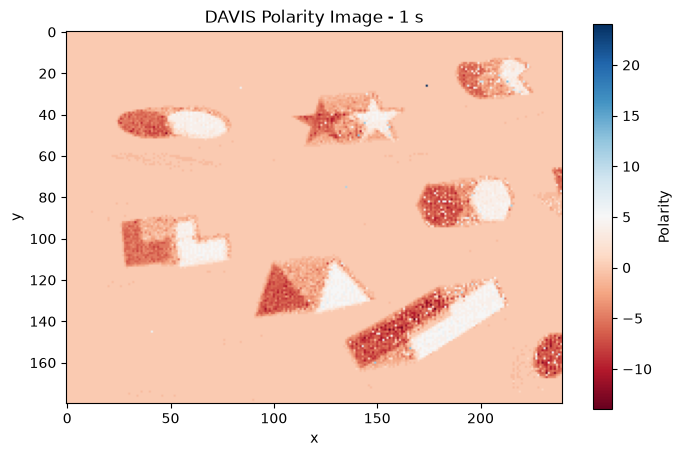

In [9]:
polarity_frame = make_polarity_frame(win, size)
plot_image(polarity_frame, f"DAVIS Polarity Image - {win_s:g} s", "Polarity", cmap="RdBu")

### 3.3 Surface of Active Events (SAE)

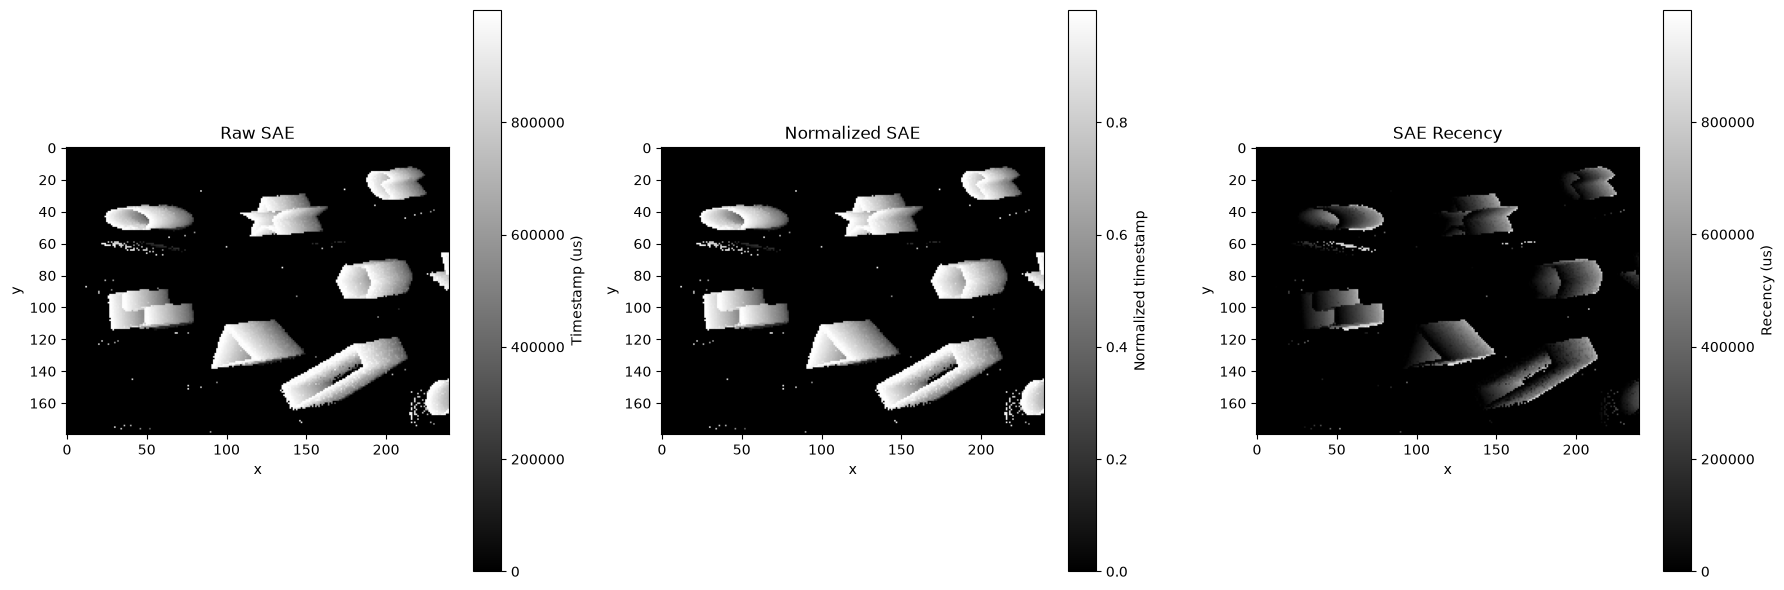

In [10]:
sae      = make_sae(win, size)
sae_norm = sae_normalized(sae, t_start, t_end)
sae_rec  = sae_recency(sae, t_end)
plot_sae(sae, sae_norm, sae_rec)

### 3.4 Time surface

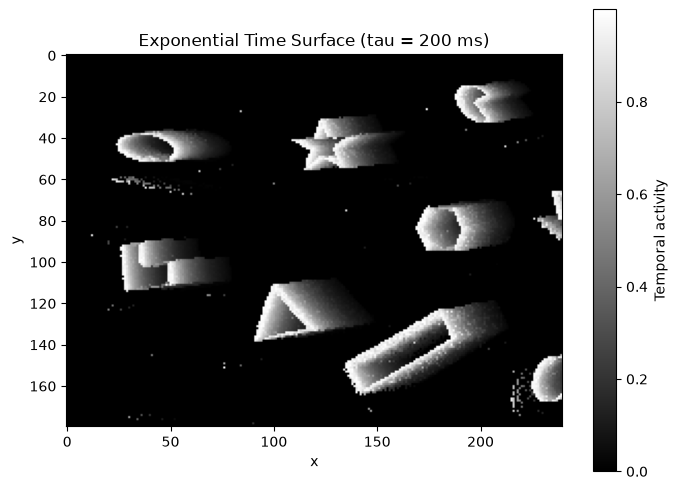

In [11]:
time_surface = make_time_surface(sae, t_now=t_end, tau_us=cfg.tau_us)
plot_image(time_surface, f"Exponential Time Surface (tau = {cfg.tau_us/1000:g} ms)",
           "Temporal activity", figsize=(8, 6))

### 3.5 Voxel grid

Voxel grid shape (bins, H, W): (10, 180, 240)


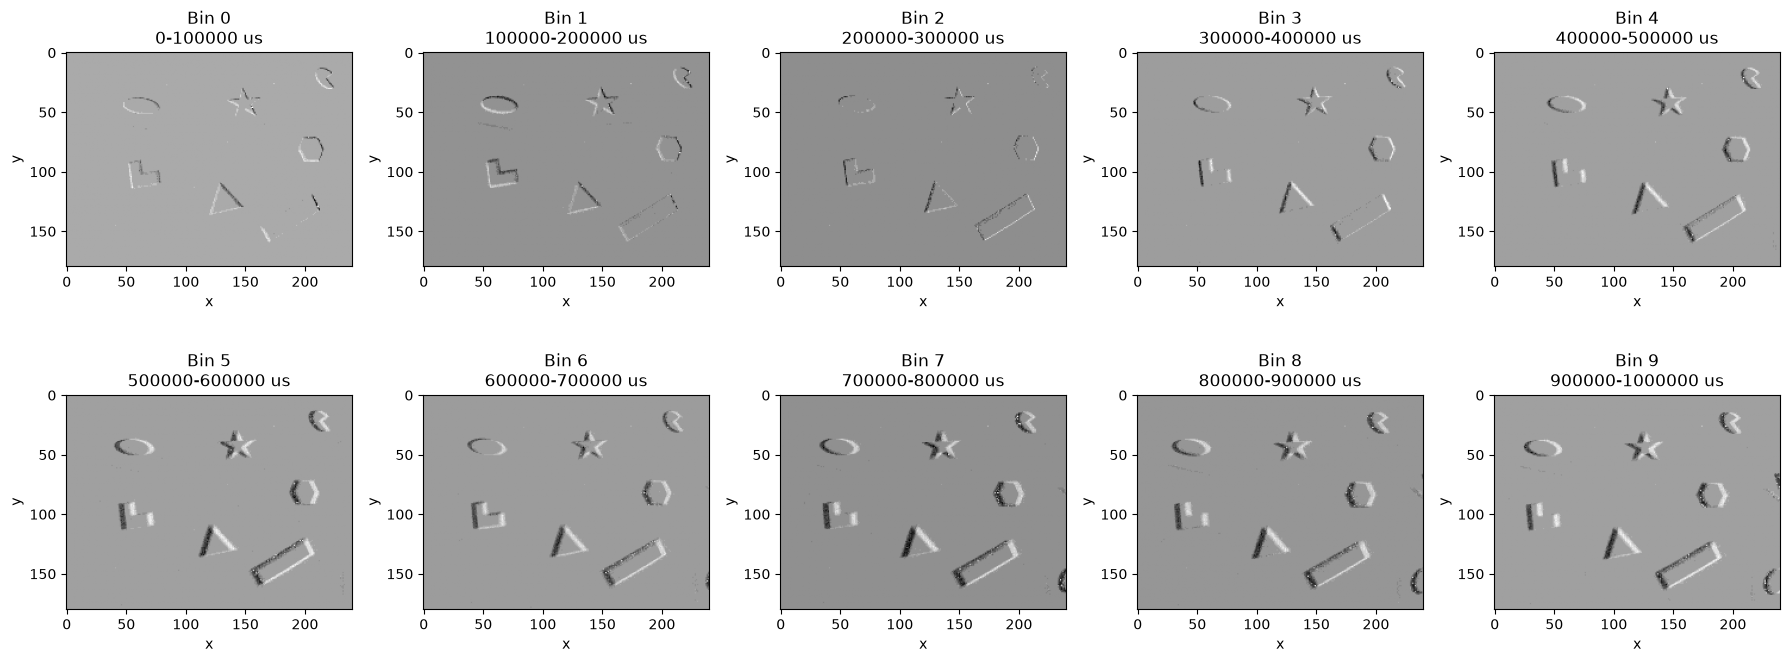

In [12]:
voxel_grid = make_voxel_grid(win, size, t_start, t_end, cfg.num_bins)
print("Voxel grid shape (bins, H, W):", voxel_grid.shape)
plot_voxel_grid(voxel_grid, t_start, t_end)

## 4. Sparse representations

### 4.1 Token-based

In [13]:
def make_tokens(win, t_start, tile_size, token_time_us):
    """
    Group events into (x_tile, y_tile, time_bin) tokens.
    Returns:
        tokens         (N, 3)  -> [x_tile, y_tile, time_bin]
        token_features (N, 6)  -> [x_tile, y_tile, time_bin, event_count, polarity_sum, mean_time]
        inverse        (E,)    -> token index of every event
    """
    t_rel = win["t"] - t_start
    keys = np.column_stack([
        win["x"] // tile_size,
        win["y"] // tile_size,
        t_rel // token_time_us,
    ])
    tokens, inverse = np.unique(keys, axis=0, return_inverse=True)
    inverse = inverse.reshape(-1)
    n = len(tokens)

    count = np.bincount(inverse, minlength=n)
    pol_sum = np.bincount(inverse, weights=signed_polarity(win["p"]), minlength=n)
    mean_t = np.bincount(inverse, weights=t_rel, minlength=n) / np.maximum(count, 1)

    features = np.column_stack([tokens, count, pol_sum, mean_t])
    return tokens, features, inverse


def plot_tokens(tokens, features, tile_size, time_bin, t_start, token_time_us):
    sel = tokens[:, 2] == time_bin
    plt.figure(figsize=(8, 6))
    plt.scatter(tokens[sel, 0] * tile_size, tokens[sel, 1] * tile_size,
                s=features[sel, 3] * 5 + 10, alpha=0.7)
    plt.gca().invert_yaxis()
    plt.xlabel("X"); plt.ylabel("Y")
    lo = time_bin * token_time_us
    plt.title(f"Token Representation - time bin {time_bin} ({lo} to {lo + token_time_us} us)")
    plt.show()

Number of tokens: 21955
Feature format: [x_tile, y_tile, time_bin, event_count, polarity_sum, mean_time]
[[ 0.00000000e+00  5.00000000e+00  9.85000000e+02  1.00000000e+00
  -1.00000000e+00  9.85999000e+05]
 [ 1.00000000e+00  2.00000000e+00  8.28000000e+02  1.00000000e+00
  -1.00000000e+00  8.28444000e+05]
 [ 1.00000000e+00  2.00000000e+00  8.32000000e+02  1.00000000e+00
  -1.00000000e+00  8.32519000e+05]
 [ 1.00000000e+00  2.00000000e+00  8.36000000e+02  3.00000000e+00
  -3.00000000e+00  8.36495667e+05]
 [ 1.00000000e+00  2.00000000e+00  8.39000000e+02  1.00000000e+00
  -1.00000000e+00  8.39224000e+05]
 [ 1.00000000e+00  2.00000000e+00  8.42000000e+02  2.00000000e+00
  -2.00000000e+00  8.42668000e+05]
 [ 1.00000000e+00  2.00000000e+00  8.44000000e+02  1.00000000e+00
  -1.00000000e+00  8.44267000e+05]
 [ 1.00000000e+00  2.00000000e+00  8.46000000e+02  1.00000000e+00
  -1.00000000e+00  8.46760000e+05]
 [ 1.00000000e+00  2.00000000e+00  8.47000000e+02  1.00000000e+00
  -1.00000000e+00  8.

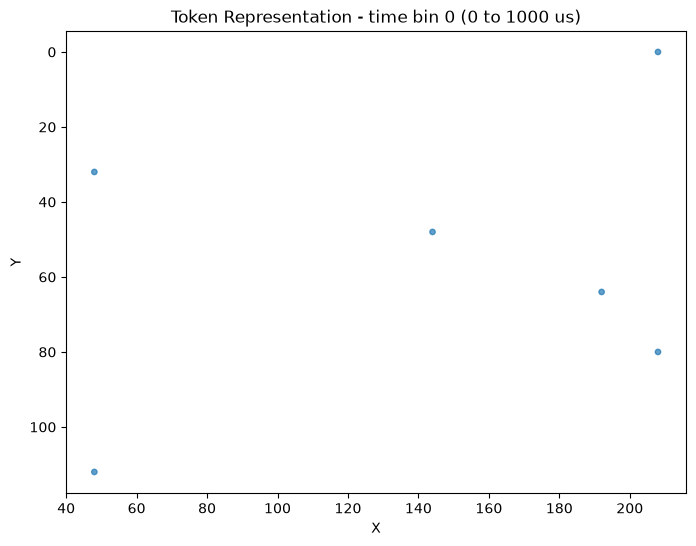

In [14]:
tokens, token_features, _ = make_tokens(win, t_start, cfg.tile_size, cfg.token_time_us)
print("Number of tokens:", len(tokens))
print("Feature format: [x_tile, y_tile, time_bin, event_count, polarity_sum, mean_time]")
print(token_features[:10])
plot_tokens(tokens, token_features, cfg.tile_size, cfg.token_bin_to_show, t_start, cfg.token_time_us)

### 4.2 Graph-based

In [15]:
def build_graph(win, spatial_radius, temporal_radius_us):
    """
    Nodes = events. Edge (i, j), i < j, if the events are within
    `spatial_radius` pixels AND `temporal_radius_us` in time.
    Returns edges (E, 2) and edge_features (E, 4) = [dx, dy, dt, dp].
    """
    gx = win["x"].astype(float)
    gy = win["y"].astype(float)
    gt = win["t"].astype(float)
    gp = win["p"]

    tree = cKDTree(np.column_stack([gx, gy]))
    pairs = tree.query_pairs(r=spatial_radius, output_type="ndarray")   # i < j, no self loops

    if len(pairs):
        keep = np.abs(gt[pairs[:, 0]] - gt[pairs[:, 1]]) <= temporal_radius_us
        pairs = pairs[keep]
        pairs = pairs[np.lexsort((pairs[:, 1], pairs[:, 0]))]           # sort by (src, dst)
    edges = pairs.astype(np.int64).reshape(-1, 2)

    src, dst = edges[:, 0], edges[:, 1]
    edge_features = np.column_stack([
        gx[dst] - gx[src],
        gy[dst] - gy[src],
        gt[dst] - gt[src],
        gp[dst].astype(float) - gp[src].astype(float),
    ])
    return edges, edge_features


def plot_graph(win, edges, max_edges=300):
    gx, gy = win["x"], win["y"]
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(gx, gy, s=5)
    segs = [[(gx[i], gy[i]), (gx[j], gy[j])] for i, j in edges[:max_edges]]
    ax.add_collection(LineCollection(segs, linewidths=0.3, colors="tab:orange"))
    ax.invert_yaxis()
    ax.set_xlabel("X"); ax.set_ylabel("Y")
    ax.set_title("Graph-based Event Representation")
    plt.show()

Nodes: 52362  Edges: 69334
Edge feature shape: (69334, 4) -> [dx, dy, dt, dp]
First 10 edges:
 [[11 13]
 [13 15]
 [15 16]
 [20 23]
 [21 23]
 [45 46]
 [50 52]
 [55 59]
 [58 60]
 [66 67]]
First 10 edge features:
 [[ -5.  -4. 435.  -1.]
 [  1.   2. 371.   1.]
 [ -2.  -1. 224.   0.]
 [ -3.   2. 387.   0.]
 [  7.   0. 337.   0.]
 [  3.  -2. 409.   0.]
 [  4.  -3.  66.   0.]
 [ -5.   1. 455.   0.]
 [ -1.   0. 333.   0.]
 [  6.   4.  21.   0.]]


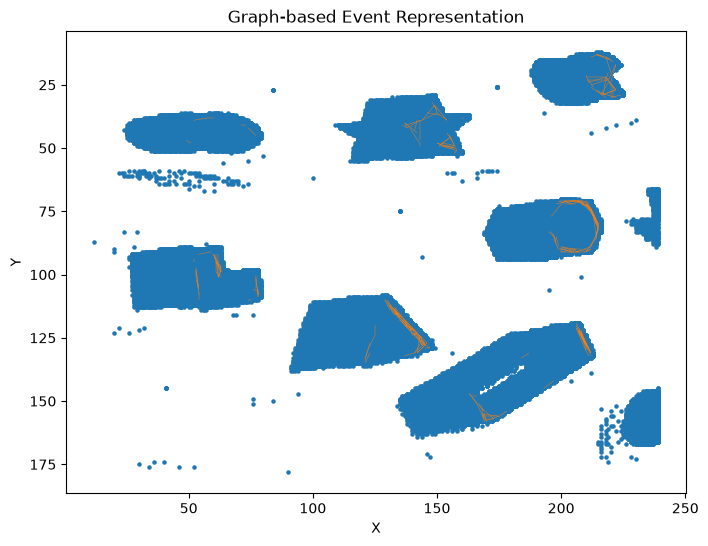

In [16]:
edges, edge_features = build_graph(win, cfg.graph_spatial_radius, cfg.graph_temporal_radius_us)
print("Nodes:", len(win), " Edges:", len(edges))
print("Edge feature shape:", edge_features.shape, "-> [dx, dy, dt, dp]")
print("First 10 edges:\n", edges[:10])
print("First 10 edge features:\n", edge_features[:10])
plot_graph(win, edges, cfg.max_edges_to_plot)

### 4.3 Point-based

In [17]:
def plot_points(win, size=2):
    on, off = win["p"] == 1, win["p"] == 0
    plt.figure(figsize=(8, 6))
    plt.scatter(win["x"][on],  win["y"][on],  s=size, label="Positive")
    plt.scatter(win["x"][off], win["y"][off], s=size, label="Negative")
    plt.gca().invert_yaxis()
    plt.xlabel("X"); plt.ylabel("Y")
    plt.title("Point-based Event Representation")
    plt.legend()
    plt.show()

Point representation shape: (52362,)
[(   0,  50,  40, 0) ( 494, 216,  14, 0) ( 648, 156,  51, 1)
 ( 669,  57, 114, 1) ( 705, 208,  91, 1) ( 705, 203,  72, 0)
 (1060, 169, 158, 1) (1199, 195,  83, 1) (1299, 210,  23, 1)
 (1412, 207,  91, 1)]


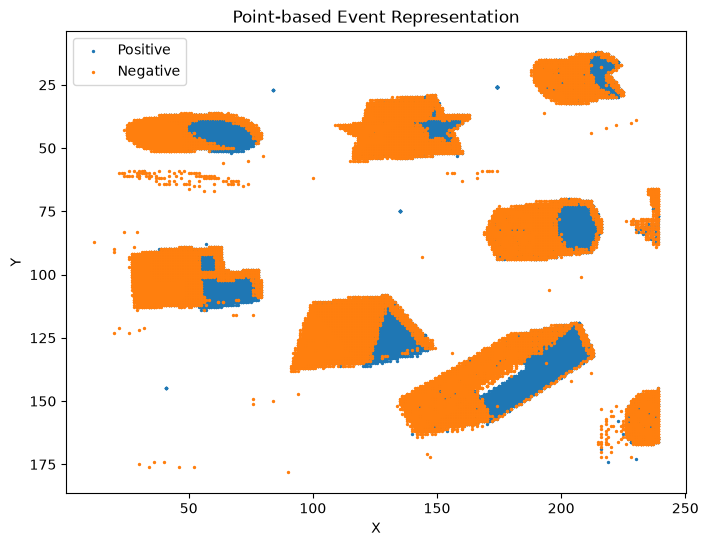

In [18]:
print("Point representation shape:", win.shape)
print(win[:10])
plot_points(win)